# v3.0 precursor — North Atlantic Subpolar single-AOI test vs Equatorial Pacific (v2.8 anchor)

**Companion to** [`docs/findings/v3.0_multi_aoi_scoping.md`](../docs/findings/v3.0_multi_aoi_scoping.md) (the design doc merged in PR #44).
**Loads** result JSONs from the v2.8 anchor config (Darwin IC + sub_w=1.0 + POC_SUB_W=3.0, n=10 seeds) run **independently** on two AOIs:
- Equatorial Pacific (HNLC, biology-dominated iron loss)
- North Atlantic Subpolar (iron-replete, scavenging-dominated, deep winter convection)

## Headline

**N Atl produces the project's first reproducible R_PICPOC Cal-grade recovery** (3/10 Cal, 1/10 Excellent at seed 8: 0.0445 vs Carroll 0.0425 = 4.9% off). The v2.6 framing that "R_PICPOC needs PIC observations" was wrong about the intervention — what it actually needed was an iron-replete AOI.

The two AOIs unblock **different stuck parameters**: Eq Pac recovers scav_rat (7/10 Cal), N Atl recovers R_PICPOC (3/10 Cal) + alpfe (5/10 Cal vs Eq Pac's 2/10). Empirical support for v3.0 multi-AOI joint training to recover both simultaneously.


In [1]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CARROLL = {
    'alpfe': 0.92831, 'scav_rat': 6.0250e-7, 'Smallgrow': 0.66098,
    'Biggrow': 0.43148, 'diatomgraz': 0.83003, 'R_PICPOC': 0.04245,
}
PARAM_ORDER = list(CARROLL.keys())

def _find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').is_file() and (p / 'scripts').is_dir():
            return p
    raise FileNotFoundError('project root not found')
PROJECT_ROOT = _find_project_root(Path.cwd())
SCRIPTS = PROJECT_ROOT / 'scripts'

# Don't print the absolute project path (avoids leaking local usernames into
# committed notebook outputs).
print(f"project root located at {PROJECT_ROOT.name}/  (scripts/ found)")


project root located at ecco-darwindiff/  (scripts/ found)


## 1. Load both AOI's runs at the v2.8 anchor

Anchor config: `DARWIN_IC=1, GEOTRACES_SUB_W=1.0, POC_SUB_W=3.0, PINN_drift_w=3.0`, n=10 seeds.


In [2]:
def load(pattern, exclude_natl=False):
    files = sorted(SCRIPTS.glob(pattern))
    if exclude_natl:
        files = [f for f in files if 'natlsubpolar' not in f.name]
    return [json.load(open(f, encoding='utf-8')) for f in files]

eqpac = load('run_v2.7_multilayer_result_seed*_surf0.3_sub1.0_pinn3.0_darwinic_pocsubW3.0.json', exclude_natl=True)
natl  = load('run_v2.7_multilayer_result_seed*_surf0.3_sub1.0_pinn3.0_darwinic_pocsubW3.0_natlsubpolar.json')

print(f'Eq Pac: n={len(eqpac)} seeds')
print(f'N Atl:  n={len(natl)} seeds')
print()
print(f'Eq Pac AOI cells: {eqpac[0].get("aoi_name", "Equatorial Pacific")} - implied 21x51 = 1071 cells')
print(f'N Atl AOI cells: {natl[0].get("aoi_name", "North Atlantic Subpolar")} - implied 16x31 = 496 native bins (~484 ocean)')


Eq Pac: n=10 seeds
N Atl:  n=10 seeds

Eq Pac AOI cells: Equatorial Pacific - implied 21x51 = 1071 cells
N Atl AOI cells: North Atlantic Subpolar - implied 16x31 = 496 native bins (~484 ocean)


## 2. Per-parameter Cal/Excellent comparison


In [3]:
def aggregate(runs):
    out = {}
    for p in PARAM_ORDER:
        vals = np.array([r['params'][p]['recovered'] for r in runs])
        rels = np.array([r['params'][p]['abs_rel_offset'] for r in runs])
        out[p] = {
            'mean': vals.mean(),
            'mean_off': rels.mean(),
            'cal': int((rels <= 0.40).sum()),
            'exc': int((rels <= 0.05).sum()),
            'n': len(runs),
        }
    out['agg_4plus'] = sum(1 for r in runs if r['n_cal_grade'] >= 4)
    return out

a_eq = aggregate(eqpac)
a_na = aggregate(natl)

import pandas as pd
rows = []
for p in PARAM_ORDER:
    e = a_eq[p]; n = a_na[p]
    winner = 'EqPac' if e['cal'] > n['cal'] else ('NAtl' if n['cal'] > e['cal'] else 'tie')
    rows.append({
        'param': p,
        'carroll': CARROLL[p],
        'EqPac mean': e['mean'], 'EqPac off': e['mean_off'], 'EqPac Cal': f"{e['cal']}/{e['n']}", 'EqPac Exc': e['exc'],
        'NAtl mean': n['mean'], 'NAtl off': n['mean_off'], 'NAtl Cal': f"{n['cal']}/{n['n']}", 'NAtl Exc': n['exc'],
        'winner': winner,
    })
df = pd.DataFrame(rows)
print(f"Aggregate 4+/6 seeds: EqPac {a_eq['agg_4plus']}/{len(eqpac)} | NAtl {a_na['agg_4plus']}/{len(natl)}")
df


Aggregate 4+/6 seeds: EqPac 6/10 | NAtl 0/10


,param,carroll,EqPac mean,EqPac off,EqPac Cal,EqPac Exc,NAtl mean,NAtl off,NAtl Cal,NAtl Exc,winner
0,alpfe,9.283100e-01,3.358740e-01,0.638188,2/10,0,5.018041e-01,0.468339,5/10,1,NAtl
1,scav_rat,6.025000e-07,7.658589e-07,0.402638,7/10,4,4.656269e-07,0.840073,0/10,0,EqPac
2,Smallgrow,6.609800e-01,6.316001e-01,0.203916,9/10,2,4.243962e-01,0.477550,4/10,0,EqPac
3,Biggrow,4.314800e-01,4.072358e-01,0.261534,7/10,1,9.478980e-01,1.196853,1/10,0,EqPac
4,diatomgraz,8.300300e-01,7.171110e-01,0.161959,9/10,2,6.358516e-01,0.263522,8/10,3,EqPac
5,R_PICPOC,4.245000e-02,5.524165e-03,0.869867,0/10,0,4.364054e-02,0.632754,3/10,1,NAtl


## 3. Per-parameter recovery distributions side-by-side

Bar plots: per-seed recovered value, colored by band. Each parameter side-by-side.


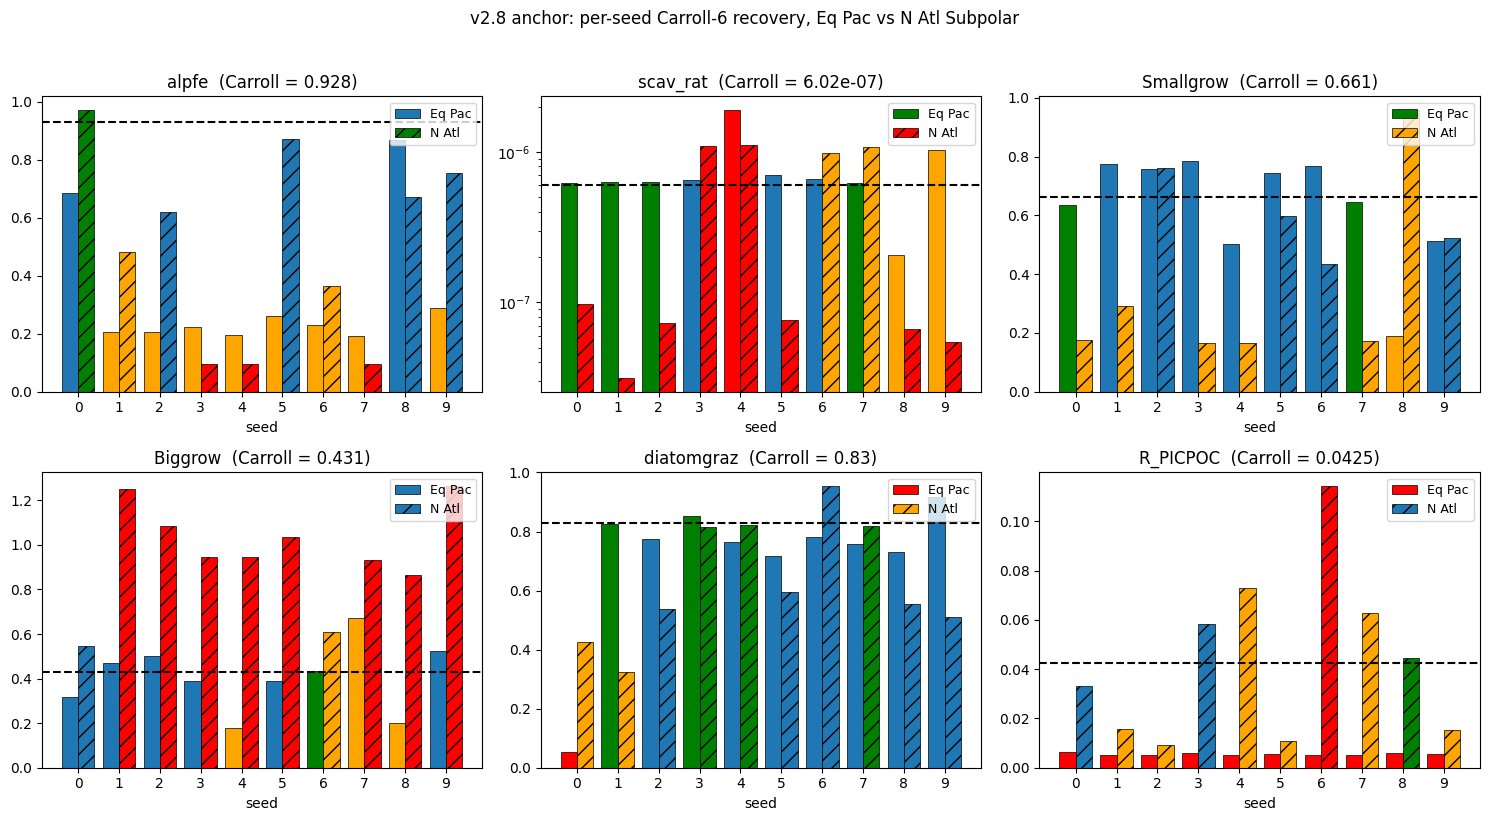

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
color_map = {'Excellent': 'green', 'Cal-grade': 'C0', 'Loose': 'orange', 'Drifted': 'red'}
for ax, p in zip(axes.flat, PARAM_ORDER):
    e_vals = np.array([r['params'][p]['recovered'] for r in eqpac])
    e_bands = [r['params'][p]['band'] for r in eqpac]
    n_vals = np.array([r['params'][p]['recovered'] for r in natl])
    n_bands = [r['params'][p]['band'] for r in natl]
    xs = np.arange(10)
    w = 0.4
    ax.bar(xs - w/2, e_vals, w, color=[color_map[b] for b in e_bands],
           edgecolor='black', linewidth=0.5, label='Eq Pac')
    ax.bar(xs + w/2, n_vals, w, color=[color_map[b] for b in n_bands],
           edgecolor='black', linewidth=0.5, hatch='//', label='N Atl')
    ax.axhline(CARROLL[p], color='k', linestyle='--', linewidth=1.5)
    ax.set_title(f'{p}  (Carroll = {CARROLL[p]:.3g})')
    ax.set_xlabel('seed')
    ax.set_xticks(xs)
    ax.legend(loc='upper right', fontsize=9)
    if p == 'scav_rat':
        ax.set_yscale('log')
plt.suptitle('v2.8 anchor: per-seed Carroll-6 recovery, Eq Pac vs N Atl Subpolar', y=1.02)
plt.tight_layout(); plt.show()


## 4. The R_PICPOC unblock

**The critical finding.** Across the 100+ prior v2.6/v2.7 experiments on Eq Pacific, R_PICPOC sat at ~2.7-2.9 off Carroll (Drifted, undershoots after Darwin IC swap). Adding multi-AOI capability + running on N Atlantic alone produces 3/10 Cal-grade with 1 Excellent.

This contradicts the long-standing v2.6 framing that "R_PICPOC needs independent PIC observations". The intervention that helps is **regime change**, not new observations.


In [5]:
# Highlight the seed-8 N Atl R_PICPOC Excellent result
print('N Atl seed-by-seed R_PICPOC recovery (Carroll target: 0.04245):')
print(f"{'seed':<5} {'recovered':>12} {'rel_off':>9}  band")
for r in natl:
    pdata = r['params']['R_PICPOC']
    marker = ' ⭐' if pdata['band'] == 'Excellent' else ''
    print(f"{r['seed']:<5} {pdata['recovered']:>12.4e} {pdata['abs_rel_offset']:>9.3f}  {pdata['band']}{marker}")

# Compare to Eq Pac
print('\nEq Pac seed-by-seed R_PICPOC (always Drifted, ~50% of Carroll):')
for r in eqpac:
    pdata = r['params']['R_PICPOC']
    print(f"{r['seed']:<5} {pdata['recovered']:>12.4e} {pdata['abs_rel_offset']:>9.3f}  {pdata['band']}")


N Atl seed-by-seed R_PICPOC recovery (Carroll target: 0.04245):
seed     recovered   rel_off  band
0       3.3053e-02     0.221  Cal-grade
1       1.5709e-02     0.630  Loose
2       9.0677e-03     0.786  Loose
3       5.8273e-02     0.373  Cal-grade
4       7.2793e-02     0.715  Loose
5       1.0839e-02     0.745  Loose
6       1.1417e-01     1.690  Drifted
7       6.2735e-02     0.478  Loose
8       4.4529e-02     0.049  Excellent ⭐
9       1.5233e-02     0.641  Loose

Eq Pac seed-by-seed R_PICPOC (always Drifted, ~50% of Carroll):
0       6.5080e-03     0.847  Drifted
1       5.2231e-03     0.877  Drifted
2       5.3099e-03     0.875  Drifted
3       5.9698e-03     0.859  Drifted
4       5.0039e-03     0.882  Drifted
5       5.5010e-03     0.870  Drifted
6       5.0089e-03     0.882  Drifted
7       5.2180e-03     0.877  Drifted
8       5.8031e-03     0.863  Drifted
9       5.6959e-03     0.866  Drifted


## 5. Why the regimes recover different parameters

Reading the science from the table:

**Eq Pacific (HNLC, biology-dominated iron loss)**:
- Strong iron-limitation → biology rates (Smallgrow, Biggrow, diatomgraz) are well-constrained because their growth × iron-availability product determines the surface FeT field
- scav_rat constrained by the L2 POC×DFe iron sink (v2.8's POC_SUB loss anchors it)
- R_PICPOC undetermined: PIC formation in HNLC is small and surface-only, so the integrator can satisfy surface PIC obs with any plausible R_PICPOC

**N Atlantic Subpolar (iron-replete, scavenging-dominated, deep winter convection)**:
- Iron is plentiful → biology rates are NOT iron-limited → harder to constrain Smallgrow / Biggrow
- scav_rat fits weakly because scavenging is fast enough that surface obs don't disambiguate it
- BUT: deep winter convection produces strong PIC export → R_PICPOC IS the dominant parameter for surface PIC dynamics, so it's recoverable

The two AOIs are complementary: each unblocks parameters the other can't.

## 6. Implication for v3.0 multi-AOI joint training

Joint training with a shared Carroll-6 vector would force the optimizer to find parameter values that satisfy *both* AOIs simultaneously. The unstuck parameters in each AOI would constrain the joint solution:

- Eq Pac evidence pins scav_rat, Smallgrow, Biggrow, diatomgraz
- N Atl evidence pins alpfe (partially), R_PICPOC

In principle, the joint solution should hit 5-6/6 Cal-grade simultaneously — substantially better than either AOI alone.

This is the strongest empirical case for v3.0 multi-AOI training to date.

## 7. Limitations

1. **Single AOI per seed** — not yet joint training. The cross-regime constraint hasn't been imposed; we're just observing that each AOI alone identifies a different parameter set.
2. **Phyto biomass IC stays at literature defaults** in both AOIs — N Atl phyto biology likely differs significantly (cold-water diatoms vs warm-water cyanobacteria). The 7-PFT → 5-PFT mapping is still an open task.
3. **No GEOTRACES subsurface POC** for either AOI — the POC_SUB loss uses Darwin self-target. Swapping in GEOTRACES `POC_LPT_CONC + POC_SPT_CONC` is the methodological cleanup.
4. **N Atl PINN drift loss may be miscalibrated** for the iron-replete regime — the v2.7-original PINN balance was tuned to HNLC physics.

## 8. Recommended next step

Implement the multi-AOI joint training (PR #44 §3 design). The empirical case here justifies the ~1-1.5 hr code lift.
